In [1]:
import os
import numpy as np
import xarray as xr
import pop_tools
import gsw
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patheffects as pe


In [2]:
# AMS widths in inches
one_col = 3.167  # 19 picas
two_col = 6.5    # 39 picas

# Set defaults
plt.rcParams.update({
    'figure.figsize': (two_col, two_col * 0.6),
    'font.size': 11,
    'axes.titlesize': 11,   # match global font size for titles
    'savefig.dpi': 300,
})


# Define Convection mask

In [3]:
path = "/Data/gfi/share/ModData/CMIP6/raw/ocean/piControl/CESM2/MLOTST/*.nc"
ds = xr.open_mfdataset(path, combine='by_coords')

/home/innag3580/.conda/envs/movie/lib/python3.10/site-packages/xarray/conventions.py:523: SerializationWarning: variable 'mlotst' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/home/innag3580/.conda/envs/movie/lib/python3.10/site-packages/xarray/conventions.py:523: SerializationWarning: variable 'mlotst' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(


In [4]:
# For each grid cell, group the MLD time series by year,
# then within each year find the maximum MLD value (deepest mixed layer),
# and finally take the mean of these annual maxima over all years
mld_mean_ann_max = ds['mlotst'].groupby('time.year').max('time').mean('year')

In [5]:
mld_mask = xr.where(mld_mean_ann_max > 1000, 1, np.nan)
mld_mask = mld_mask.roll(nlon=-100).fillna(0)

/home/innag3580/.conda/envs/movie/lib/python3.10/site-packages/dask/array/reductions.py:640: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


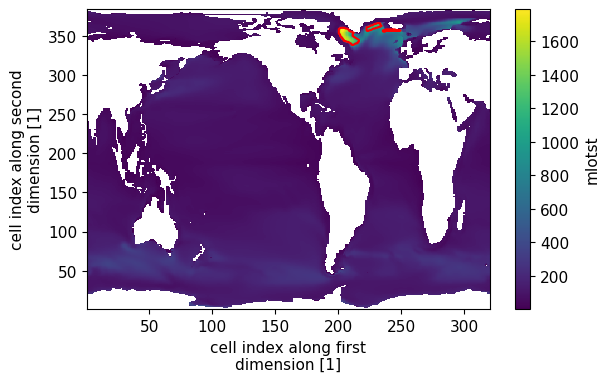

In [6]:
mld_mean_ann_max.roll(nlon=-100).plot()
mld_mask.plot.contour(levels=[0.5], colors='r')

# Define SPNA mask

"The SPNA region used to define SPNA SST and SSS is 60° W–0° and 50° N–65° N." Dai et al. (2025)

https://www.nature.com/articles/s41612-025-01190-x

In [7]:
grid_name = 'POP_gx1v7'
region_defs_lab = {'LabradorSea': [{'match': {'REGION_MASK': [8]}, 'bounds': {'TLAT': [55.0, 65.0],'TLONG': [290., 335.]}}]} 
lab_mask3d = pop_tools.region_mask_3d(grid_name, region_defs=region_defs_lab, mask_name='lab')
lab_mask3d = lab_mask3d.sum('region') # apparently necessary even in this case

region_defs_irm = {'IrmingerSea': [{'match': {'REGION_MASK': [6]}, 'bounds': {'TLAT': [55., 65.],'TLONG': [300., 335.]}}]}
irm_mask3d = pop_tools.region_mask_3d(grid_name, region_defs=region_defs_irm, mask_name='irm')
irm_mask3d = irm_mask3d.sum('region')

region_defs_esp = {'ESP': [{'match': {'REGION_MASK': [6]}, 'bounds': {'TLAT': [50., 65.],'TLONG': [335., 359.]}}],}
esp_mask3d = pop_tools.region_mask_3d(grid_name, region_defs=region_defs_esp, mask_name='esp')
esp_mask3d = esp_mask3d.sum('region')

region_defs_csp = {'NorthAtlantic': [{'match': {'REGION_MASK': [6]}, 'bounds': {'TLAT': [50., 55.],'TLONG': [300., 335.]}}],
                  'LabradorSea': [{'match': {'REGION_MASK': [8]}, 'bounds': {'TLAT': [50., 55.]}}]}
csp_mask3d = pop_tools.region_mask_3d(grid_name, region_defs=region_defs_csp, mask_name='csp')
csp_mask3d = csp_mask3d.sum('region')

lab_mask3d = lab_mask3d.roll(nlon=-100)
irm_mask3d = irm_mask3d.roll(nlon=-100)
esp_mask3d = esp_mask3d.roll(nlon=-100)
csp_mask3d = csp_mask3d.roll(nlon=-100)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


# MAP

In [8]:
# Define file path and name
path = '/Data/skd/scratch/innag3580/comp/averages/'
temp_file = 'TEMP_mean_185001-185912.nc'
salt_file = 'SALT_mean_185001-185912.nc'

# Load data
ds_temp = xr.open_dataset(os.path.join(path, temp_file))
ds_salt = xr.open_dataset(os.path.join(path, salt_file))

CT = gsw.conversions.CT_from_pt(ds_salt['SALT'], ds_temp['TEMP'])
sigma2 = gsw.density.sigma2(ds_salt['SALT'], CT)
sigma2 = xr.DataArray(sigma2, name='DENS2', dims=ds_temp['TEMP'].dims, coords=ds_temp['TEMP'].coords)

/home/innag3580/.conda/envs/movie/lib/python3.10/site-packages/xarray/core/computation.py:771: RuntimeWarning: invalid value encountered in sigma2
  result_data = func(*input_data)


In [9]:
# Prepare density field for plotting
ds_dens = ds_temp
ds_dens = ds_dens.drop_vars('TEMP')
ds_dens['DENS2'] = sigma2

# weighted mean of upper 500 meter denisty
slice_upper_500  = slice(5e2, 5.5e3)
weights = (ds_dens.dz * ds_dens.TAREA).fillna(0)
ds_dens['DENS2'] = ds_dens.DENS2.sel(z_t=slice_upper_500).weighted(weights).mean(dim=['z_t','time']).squeeze()
#ds_dens = ds_dens.sel(z_t=slice_upper_500).mean(dim=['z_t','time'])

replacement_value = 0
ds_dens['TLAT'] = xr.where(
    np.logical_or(np.isnan(ds_dens['TLAT']), np.logical_or(np.isinf(ds_dens['TLAT']), np.ma.getmask(ds_dens['TLAT']))),
    replacement_value,
    ds_dens['TLAT'])
ds_dens['TLONG'] = xr.where(
    np.logical_or(np.isnan(ds_dens['TLONG']), np.logical_or(np.isinf(ds_dens['TLONG']), np.ma.getmask(ds_dens['TLONG']))),
    replacement_value,
    ds_dens['TLONG'])

In [10]:
plotting_data = ds_dens.DENS2

cbar_kwargs = {
    'orientation': 'horizontal',
    'shrink': 0.8,
    'aspect': 40,
    'label': r'Surface Density $\sigma_2$ [$\frac{kg}{m^3} -1000$]',
    'pad': 0.05
}

In [11]:
vmin = 33
vmax = 36.5

# Discretize colormap
levels = np.arange(vmin, vmax, 0.25)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=len(levels)-1)

# Specify ticks for the colorbar
colorbar_ticks = np.arange(vmin, vmax, 1)  # Adjust the step to reduce the number of ticks

# Create a new restricted colormap using cmo.dense
restricted_cmap = ListedColormap(cmo.dense(np.linspace(0, 1, 256)))

nature_coast = cartopy.feature.NaturalEarthFeature('physical', 'land', '50m', linewidth=0.3, edgecolor='black', facecolor='whitesmoke')


/home/innag3580/.conda/envs/movie/lib/python3.10/site-packages/dask/array/reductions.py:640: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/home/innag3580/.conda/envs/movie/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1614: UserWarning: The following kwargs were not used by contour: 'path_effects'
  result = super().contour(*args, **kwargs)


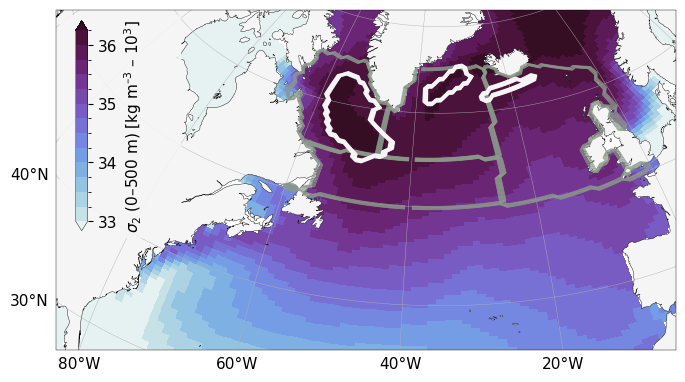

In [17]:

# 1. Create figure
fig, ax_map = plt.subplots(
    figsize=(8, 6), 
    subplot_kw={'projection': ccrs.Orthographic(central_latitude=35, central_longitude=-35)}
)

ax_map.set_extent([-90, -5, 35, 65], crs=ccrs.PlateCarree())

# 2. Main Plot (Density Map)
pc = plotting_data.plot.pcolormesh(
    ax=ax_map, transform=ccrs.PlateCarree(), x='TLONG', y='TLAT',
    cmap=restricted_cmap, norm=norm, add_colorbar=False
)

# 3. Colourbar with Copernicus Units [kg m–3 – 10³]
cbar_axes = fig.add_axes([0.15, 0.41, 0.015, 0.35])
cbar = fig.colorbar(pc, cax=cbar_axes, orientation='vertical')
cbar.set_ticks(colorbar_ticks)
# Note: \text{--} or unicode – for the en dash
cbar.set_label(r'$\sigma_{2}$ (0–500 m) [kg m$^{–3}$ – 10$^{3}$]')

for spine in cbar.ax.spines.values():
    spine.set_linewidth(0.3)

# 4. White background box for colorbar - MOVED DOWN
cbar_axes.set_zorder(2)
# Adjusted: y-coordinate moved from 0.43 to 0.40
white_box = fig.add_artist(patches.Rectangle(
    (0.13, 0.40), 0.15, 0.37, transform=fig.transFigure, 
    color='whitesmoke', zorder=1, alpha=0.9
))

# 5. Gridlines and Coordinate Formatting (30° N style)
gl = ax_map.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), zorder=1, linewidth=0.3)
gl.right_labels = False
gl.top_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# 6. Coastline and Basin Contours
ax_map.add_feature(nature_coast, zorder=1)
basin_color = '#8A9A8A'
for mask in [lab_mask3d, irm_mask3d, esp_mask3d, csp_mask3d]:
    ax_map.contour(
        ds_temp.TLONG, ds_temp.TLAT, mask.roll(nlon=+100),
        transform=ccrs.PlateCarree(), colors=basin_color, linewidths=0.5, zorder=2
    )

# 7. MLD Line - Whitesmoke with black outline for visibility
mld_color = 'whitesmoke'
ax_map.contour(
    ds_temp.TLONG, ds_temp.TLAT, mld_mask.roll(nlon=+100),
    transform=ccrs.PlateCarree(), 
    colors=mld_color, 
    linewidths=1.2, 
    zorder=3,
    path_effects=[pe.withStroke(linewidth=2, foreground='black')]
)

# 9. Spines
for spine in ax_map.spines.values():
    spine.set_linewidth(0.3)

# 10. Save (No transparency, 300 DPI)
plt.savefig('Figure_Density_map.png', bbox_inches='tight', dpi=300, transparent=False, facecolor='white')